# Análise qualitativa

Notebook para análise do dataset codificado (`dataset_processado.xlsx`).

In [21]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REQUIRED = ["pandas", "matplotlib", "seaborn", "numpy", "openpyxl"]

print("Python:", sys.executable)
print("\nPacotes necessários:")
for pkg in REQUIRED:
    mod = importlib.import_module(pkg)
    version = getattr(mod, "__version__", "—")
    print(f"  ✓ {pkg} {version}")

# Estilo padrão dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

Python: /Users/MaluEconomista/Documents/SIMONE_DISS/.venv/bin/python

Pacotes necessários:
  ✓ pandas 3.0.3
  ✓ matplotlib 3.11.0
  ✓ seaborn 0.13.2
  ✓ numpy 2.4.6
  ✓ openpyxl 3.1.5


In [22]:
# Caminho do dataset (relativo à raiz do projeto)
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "dados_qual" / "processamento" / "dataset_processado.xlsx"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {DATA_PATH}")

df_longo = pd.read_excel(DATA_PATH, sheet_name="formato_longo", engine="openpyxl")

print(f"formato_longo: {df_longo.shape[0]} linhas × {df_longo.shape[1]} colunas")

df_longo.head()

formato_longo: 300 linhas × 6 colunas


,id_passagem,document,Domínio,Sub-domínio,Sub-domínio detalhado,quotation
0,1,JMTRANSCRIPT1,Aspectos clínicos da criança autista,Atraso (não especificado),NaN,"00:00:36 Mãe João Mateus: Eu sempre observei, ..."
1,1,JMTRANSCRIPT1,Aspectos clínicos da criança autista,Autismo explicitamente mencionado,NaN,"00:00:36 Mãe João Mateus: Eu sempre observei, ..."
2,1,JMTRANSCRIPT1,Aspectos clínicos da criança autista,TDAH explicitamente mencionado,NaN,"00:00:36 Mãe João Mateus: Eu sempre observei, ..."
3,2,JMTRANSCRIPT1,Lacunas no suporte institucionalizado,Morosidade na provisão do serviço,NaN,"00:01:56 Hellen: Além daquilo, ele faz homoter..."
4,3,JMTRANSCRIPT1,Aspectos clínicos da criança autista,"Dificuldade de atenção, concentração e foco",NaN,"00:02:22 Mãe João Mateus: Sim, o João Matheus ..."


## Descritivos do dataset

Panorama do corpus: passagens analisadas, estrutura das categorias e volume de codificações.

In [23]:
from functions import descreve_dataset

tabela_descritivos = descreve_dataset(df_longo, abrir_html=True)

### Descritivos do dataset codificado

,Indicadores,Definição,Valor
0,Passagens,Trechos citados das entrevistas analisados (un...,167
1,Transcrições,Entrevistas distintas de onde as passagens for...,9
2,Domínios,Categorias de primeiro nível presentes no corpus.,13
3,Subdomínios,Categorias de segundo nível presentes no corpus.,81
4,Subdomínios detalhados,Categorias de terceiro nível preenchidas no co...,37
5,Total de codificações,Atribuições Domínio + Sub-domínio realizadas. ...,300
6,Média de codificações por passagem,Total de codificações ÷ número de passagens.,"1,80"
7,Média de passagens por domínio,"Em média, quantas passagens distintas cada dom...","17,46"



Tabela HTML salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/descritivos_dataset.html


Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/diagrama_descritivo_codificacoes.png


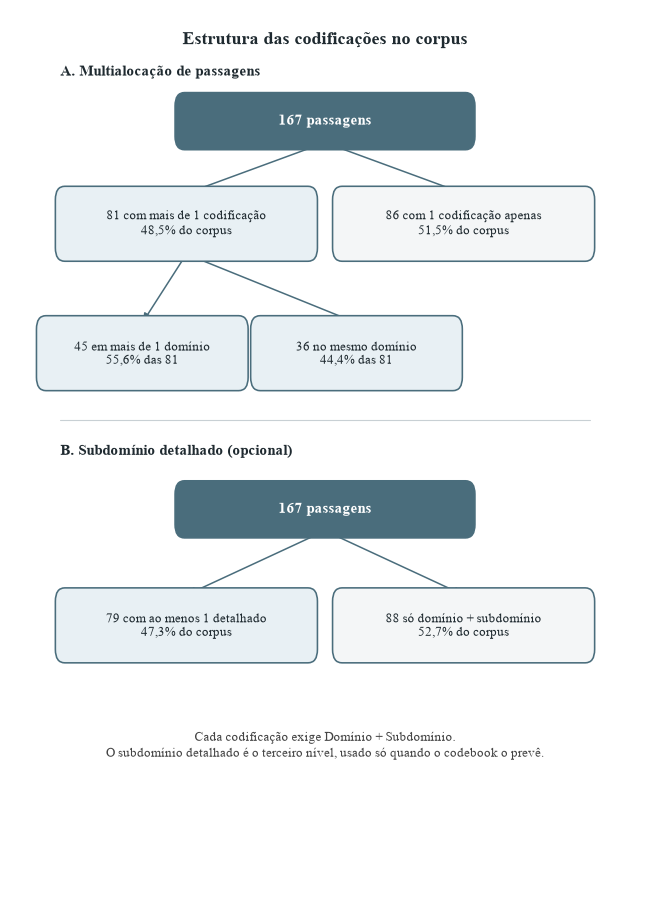

{'passagens': 167,
 'multi': 81,
 'unica': 86,
 'multi_dominio': 45,
 'mesmo_dominio': 36,
 'com_detalhado': 79,
 'sem_detalhado': 88}

In [24]:
from functions import diagrama_descritivo

contagens_diagrama, fig_diagrama = diagrama_descritivo(
    df_longo,
    save_path="diagrama_descritivo_codificacoes.png",
)
contagens_diagrama


## Coocorrência entre domínios

Matriz de **contagem**: cada célula fora da diagonal é o número de passagens únicas alocadas nos dois domínios ao mesmo tempo. A diagonal é o total de passagens de cada domínio. O overlap é esperado pelo desenho de multi-alocação; a matriz só torna o grau desse overlap legível.


### Pares de domínios com maior coocorrência (top 10)

,Domínio A,Domínio B,Passagens em comum
0,Atitudes Parentais na era da cidadania digital,Parentalidade na era da cidadania digital,11
1,Parentalidade na era da cidadania digital,Hábitos com tecnologia,7
2,Atitudes Parentais na era da cidadania digital,Valor da tecnologia,6
3,Hábitos com tecnologia,Valor da tecnologia,6
4,Atitudes Parentais na era da cidadania digital,Hábitos com tecnologia,5
5,Atitudes Parentais na era da cidadania digital,O papel da tecnologia no desenvolvimento de cr...,4
6,Hábitos com tecnologia,Bem-Estar Infantil na era da cidadania digital,4
7,Parentalidade na era da cidadania digital,Bem-Estar Infantil na era da cidadania digital,4
8,Aspectos clínicos da criança autista,Lacunas no suporte institucionalizado,3
9,Hábitos com tecnologia,Dispositivos tecnológicos comuns,3


Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/matriz_coocorrencia_dominios.png


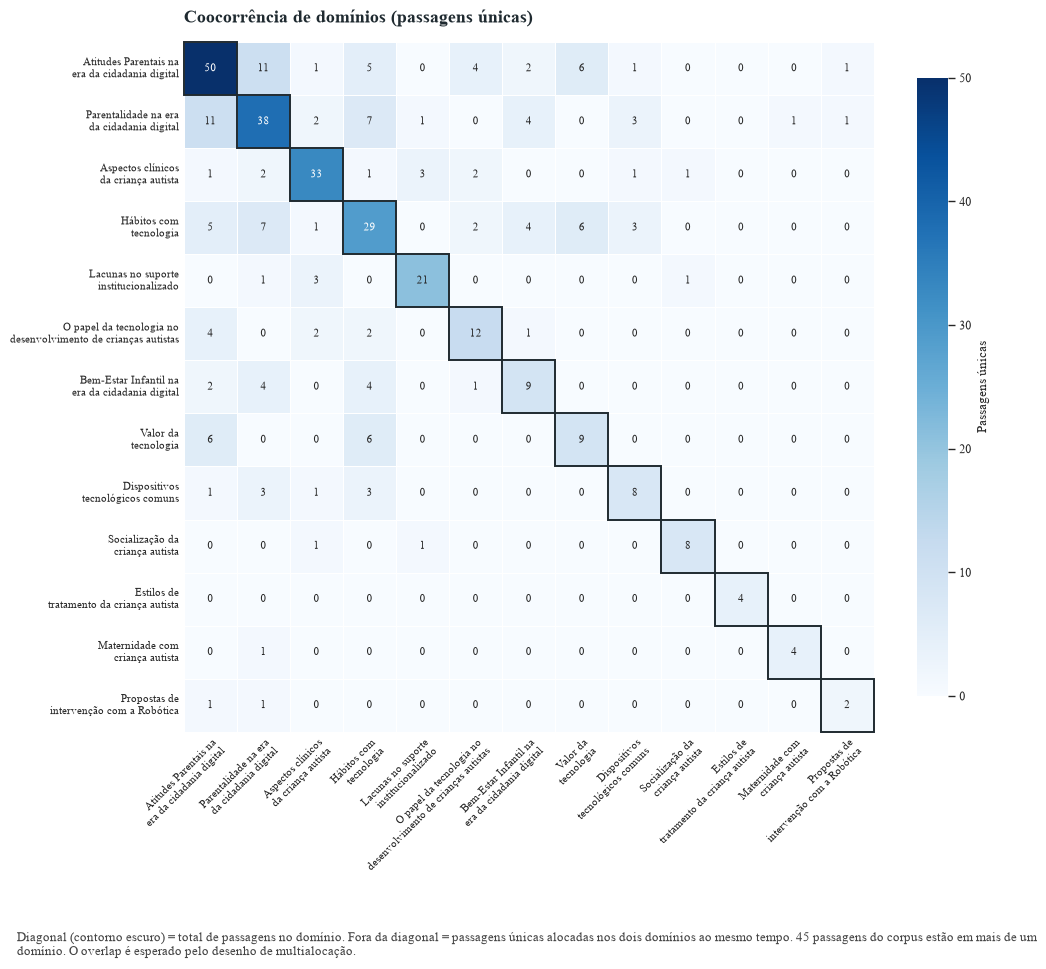

In [25]:
from functions import matriz_coocorrencia_dominios

matriz_dominios, pares_coocorrencia, fig_coocorrencia = matriz_coocorrencia_dominios(
    df_longo,
    save_path="matriz_coocorrencia_dominios.png",
)


## Coocorrência de subdomínios (intradomínio)

Heatmap **por domínio** com overlap: só entram domínios em que alguma passagem recebeu ≥2 subdomínios. Diagonal = passagens do subdomínio; fora da diagonal = passagens com os dois subdomínios na mesma fala.


Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/heatmap_subdominios_parentalidade_na_era_da_cidadania_digital.png


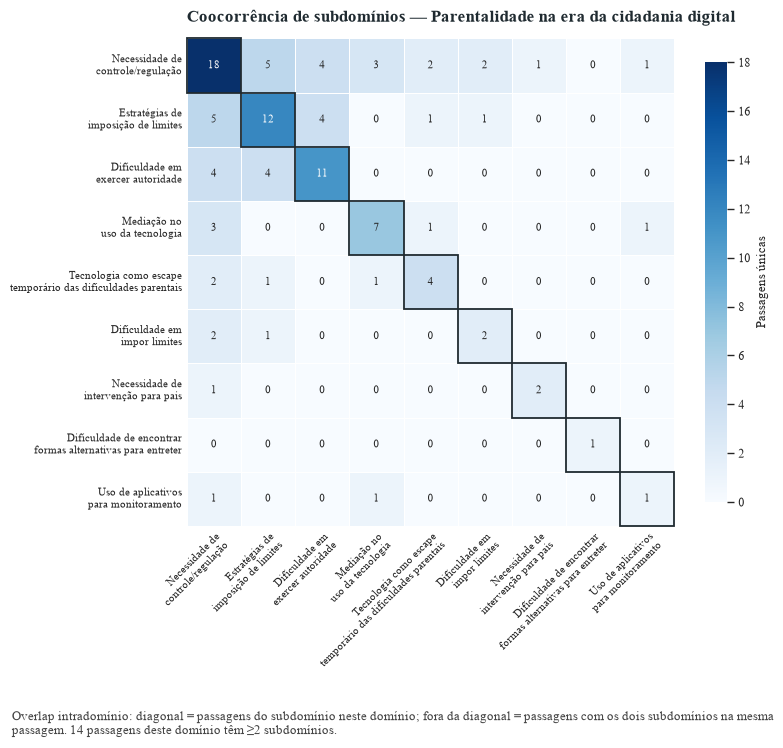

Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/heatmap_subdominios_aspectos_clinicos_da_crianca_autista.png


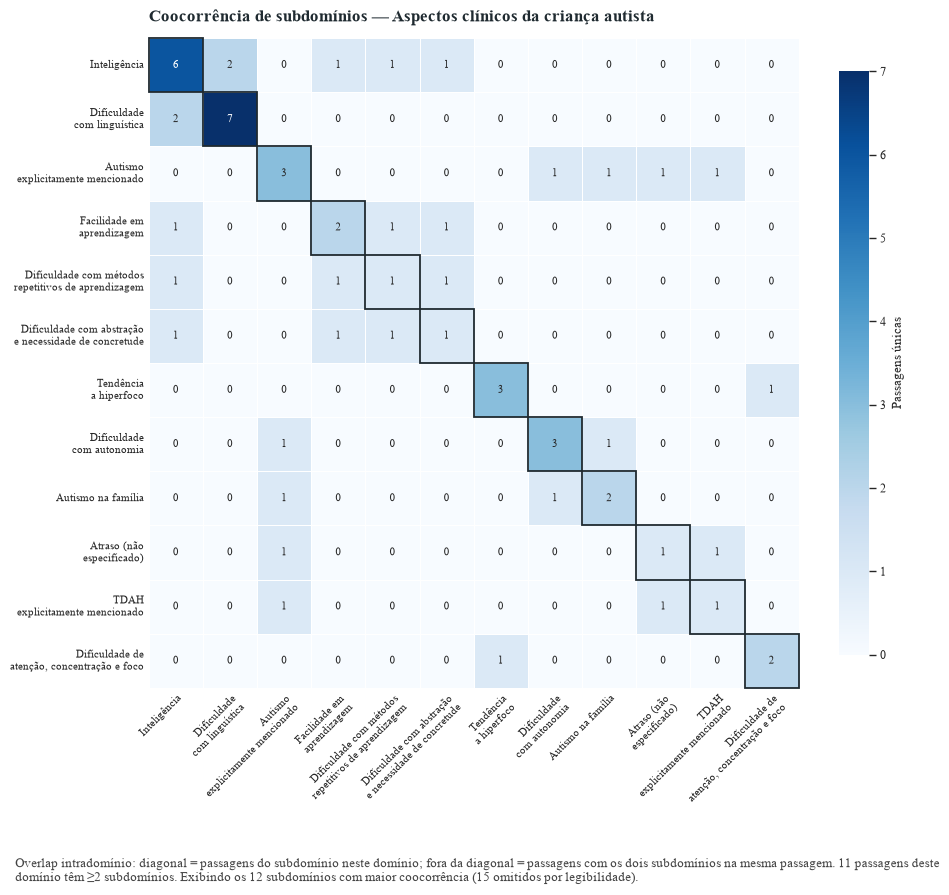

Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/heatmap_subdominios_atitudes_parentais_na_era_da_cidadania_digital.png


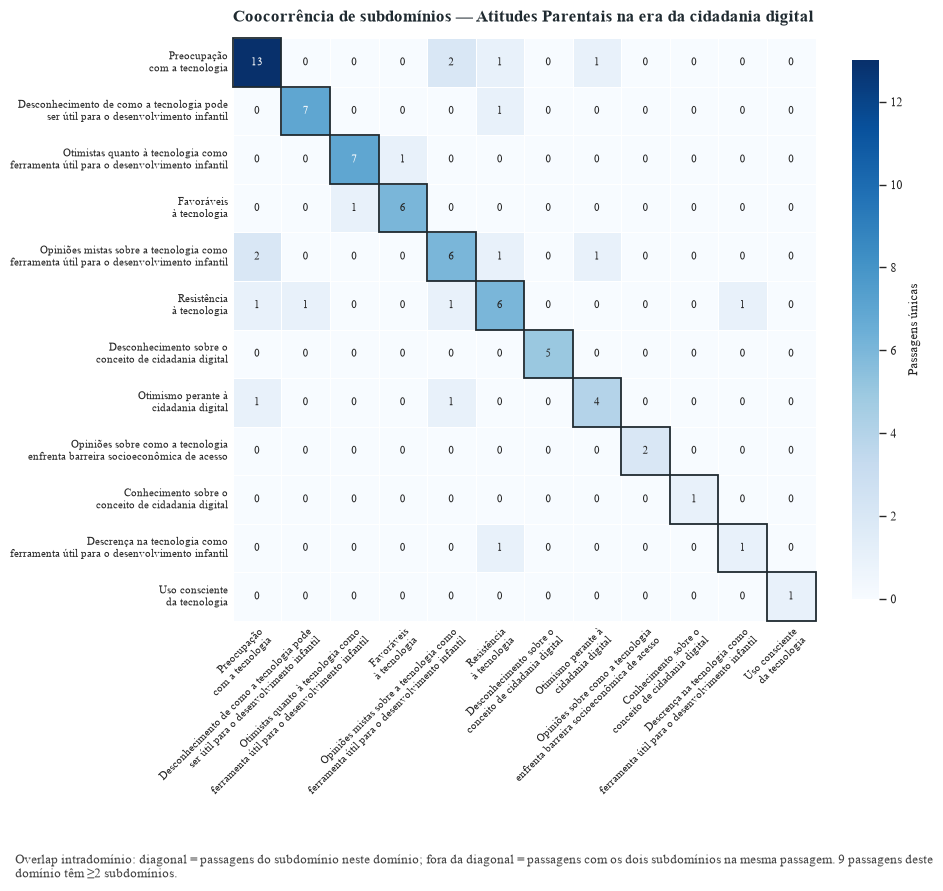

Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/heatmap_subdominios_lacunas_no_suporte_institucionalizado.png


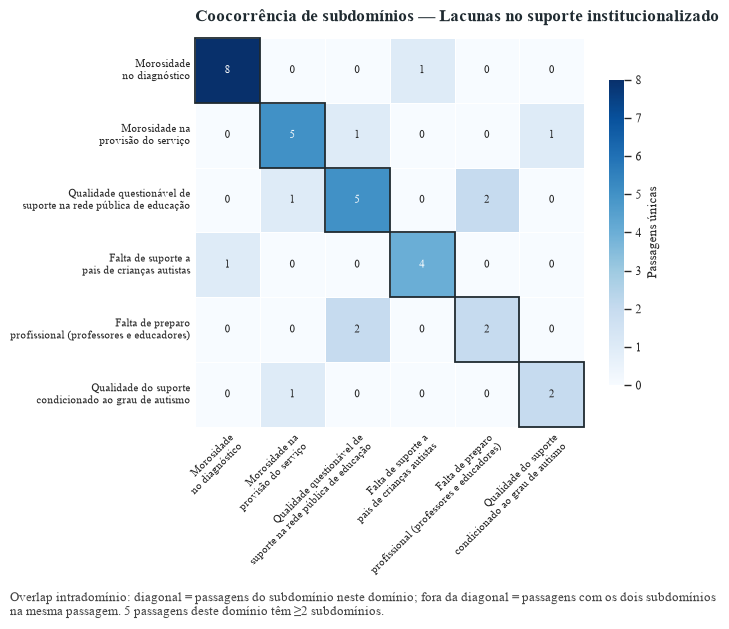

Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/heatmap_subdominios_o_papel_da_tecnologia_no_desenvolvimento_de_cria.png


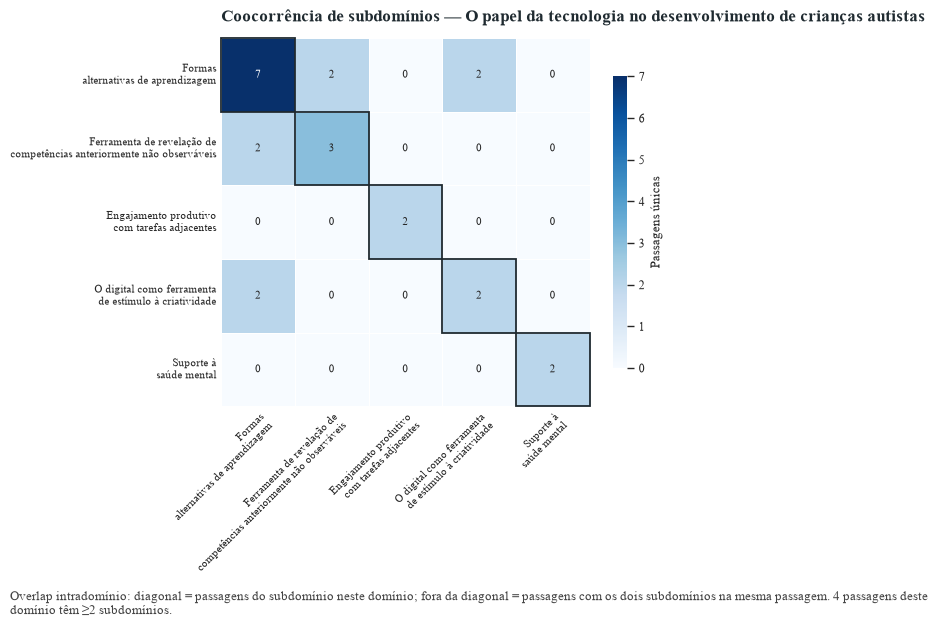

Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/heatmap_subdominios_valor_da_tecnologia.png


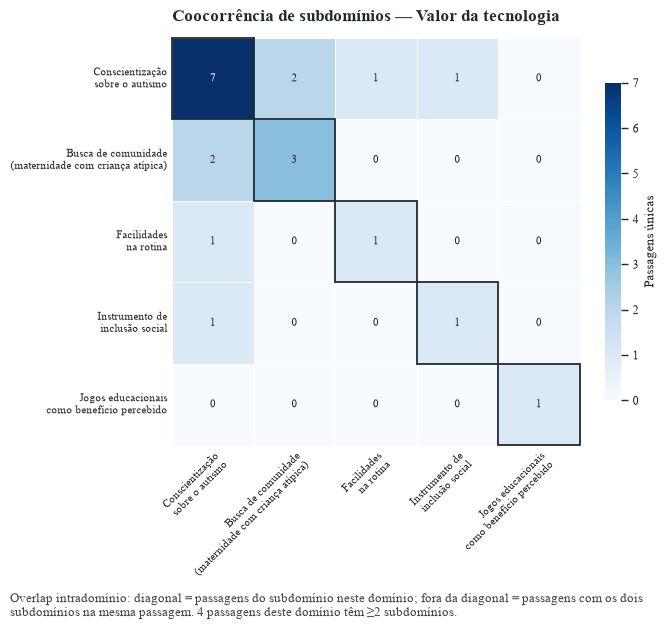

Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/heatmap_subdominios_maternidade_com_crianca_autista.png


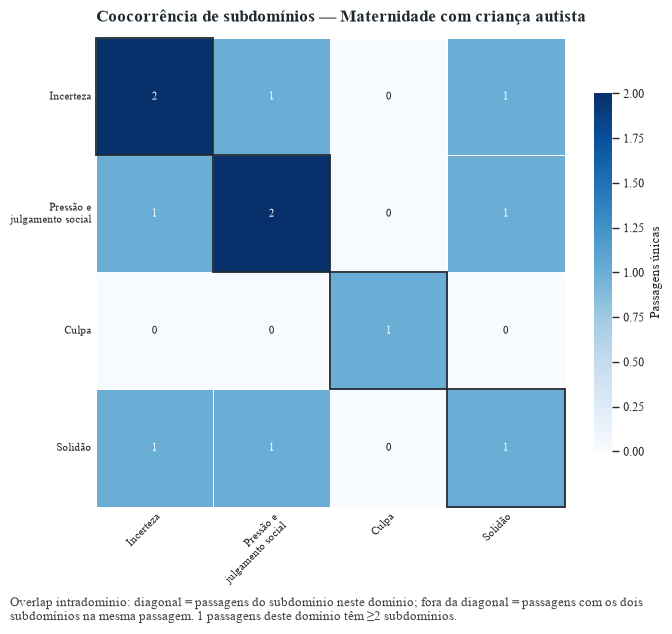

In [26]:
from functions import heatmap_coocorrencia_subdominios

# dominio=None: um heatmap por domínio com overlap intradomínio
matrizes_subdominios, figs_subdominios = heatmap_coocorrencia_subdominios(
    df_longo,
    save_path="heatmap_subdominios.png",
)

# Exemplo de um domínio só:
# heatmap_coocorrencia_subdominios(
#     df_longo,
#     dominio="Parentalidade na era digital",
#     save_path="heatmap_subdominios_parentalidade.png",
# )


## Inventário de caminhos

Tabela completa dos caminhos de codificação (`Domínio > Sub-domínio > Detalhado`) com o número de **passagens únicas** em cada um. Serve de referência para prevalência de caminhos (complementa `qual1` / `qual2` em diante). Formato pronto para copiar ao Google Docs / Word.


In [27]:
from functions import inventario_caminhos

tabela_inventario = inventario_caminhos(
    df_longo,
    abrir_html=True,
    caminho_html="inventario_caminhos.html",
)


### Inventário de caminhos de codificação

,#,Caminho,Domínio,Sub-domínio,Sub-domínio detalhado,Passagens únicas
0,1,Parentalidade na era da cidadania digital > Ne...,Parentalidade na era da cidadania digital,Necessidade de controle/regulação,—,18
1,2,Hábitos com tecnologia > Obtenção e disseminaç...,Hábitos com tecnologia,Obtenção e disseminação de informação (pais),—,9
2,3,Hábitos com tecnologia > Uso comum > Entreteni...,Hábitos com tecnologia,Uso comum,Entretenimento (assistir desenho),8
3,4,Lacunas no suporte institucionalizado > Morosi...,Lacunas no suporte institucionalizado,Morosidade no diagnóstico,—,8
4,5,Atitudes Parentais na era da cidadania digital...,Atitudes Parentais na era da cidadania digital,Desconhecimento de como a tecnologia pode ser ...,—,7
...,...,...,...,...,...,...
99,100,Socialização da criança autista > Experiência ...,Socialização da criança autista,Experiência mista de socialização,—,1
100,101,Socialização da criança autista > Experiência ...,Socialização da criança autista,Experiência negativa de socialização,Mais facilidade para socializar fora da faixa ...,1
101,102,Valor da tecnologia > Facilidades na rotina,Valor da tecnologia,Facilidades na rotina,—,1
102,103,Valor da tecnologia > Instrumento de inclusão ...,Valor da tecnologia,Instrumento de inclusão social,—,1



Tabela HTML salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/inventario_caminhos.html


## Frequência de categorias

Contagem de **passagens únicas** (`id_passagem`) por categoria.

- **`logica="coluna_simples"`** (padrão): conta valores de uma coluna (ex.: `Domínio`).
- **`logica="hierarquia"`**: filtra um `dominio` e plota os **3 sub-domínios** mais frequentes. Use `agregacao_outros=True` para somar o restante em **Outros** (mínimo 2 sub-domínios no domínio).
- **`logica="subdominio_detalhado"`**: filtra um caminho `dominio` › `subdominio` e plota os **Sub-domínios detalhados** (prevalência no caminho; percentagens podem não somar 100%).

In [28]:
from functions import plotar_categorias

### Domínios

### Frequência de Domínios Relevantes

,domínio,passagens,prevalência (%)
0,Atitudes Parentais na era da cidadania digital,50,"29,9%"
1,Parentalidade na era da cidadania digital,38,"22,8%"
2,Aspectos clínicos da criança autista,33,"19,8%"
3,Hábitos com tecnologia,29,"17,4%"
4,Lacunas no suporte institucionalizado,21,"12,6%"
5,O papel da tecnologia no desenvolvimento de cr...,12,"7,2%"
6,Bem-Estar Infantil na era da cidadania digital,9,"5,4%"
7,Valor da tecnologia,9,"5,4%"
8,Dispositivos tecnológicos comuns,8,"4,8%"
9,Socialização da criança autista,8,"4,8%"


Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/qual1.png


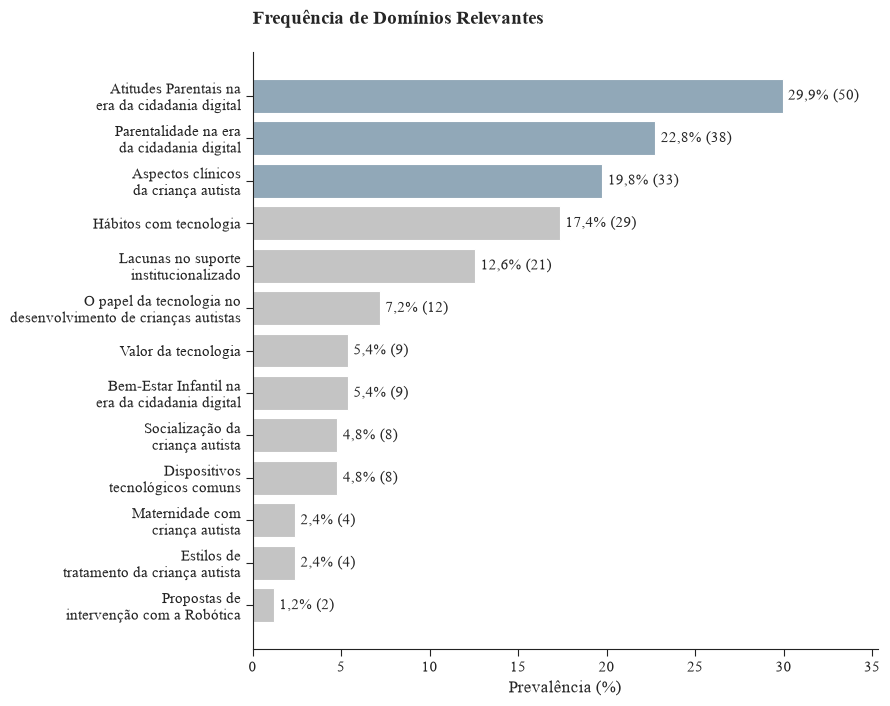

(                                              domínio  passagens  \
 0      Atitudes Parentais na era da cidadania digital         50   
 1           Parentalidade na era da cidadania digital         38   
 2                Aspectos clínicos da criança autista         33   
 3                              Hábitos com tecnologia         29   
 4               Lacunas no suporte institucionalizado         21   
 5   O papel da tecnologia no desenvolvimento de cr...         12   
 6      Bem-Estar Infantil na era da cidadania digital          9   
 7                                 Valor da tecnologia          9   
 8                    Dispositivos tecnológicos comuns          8   
 9                     Socialização da criança autista          8   
 10           Estilos de tratamento da criança autista          4   
 11                    Maternidade com criança autista          4   
 12            Propostas de intervenção com a Robótica          2   
 
    prevalência (%)  
 0        

In [29]:
plotar_categorias(
    data=df_longo,
    coluna="Domínio",
    logica="coluna_simples",
    titulo="Frequência de Domínios Relevantes",
    prevalencia=True,
    tabela=True,
    save_path="qual1.png",
)

O foco principal das entrevistas analisadas foi extrair opiniões dos pais e responsáveis sobre a tecnologia como ferramenta pedagógica, assim como percepções acerca da infância na era digital. Os entrevistados também compartilharam suas experiências de parentalidade, isto é, como é ter sua autoridade mediada pelos dispositivos digitais e pela cultura digital. A terceira e última categoria, "hábitos com tecnologia", descreve passagens em que pais e responsáveis explicam e exemplificam não só como seus filhos se relacionam com a tecnologia, mas como também todo o núcleo familiar se organiza em torno da cultura do digital. 

### Sub-domínios

### Frequência de subdomínios: atitudes parentais

,sub-domínio,passagens,prevalência (%)
0,Preocupação com a tecnologia,13,"26,0%"
1,Desconhecimento de como a tecnologia pode ser ...,7,"14,0%"
2,Otimistas quanto à tecnologia como ferramenta ...,7,"14,0%"


Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/qual2.png


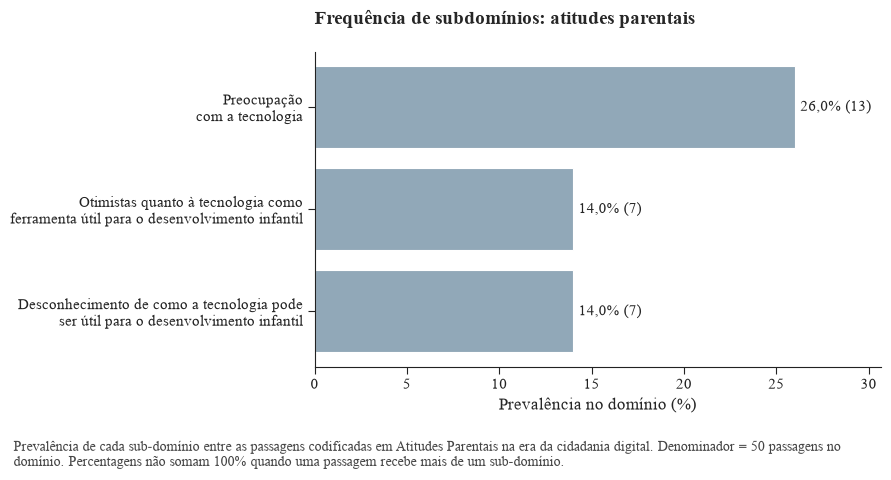

(                                         sub-domínio  passagens  \
 0                       Preocupação com a tecnologia         13   
 1  Desconhecimento de como a tecnologia pode ser ...          7   
 2  Otimistas quanto à tecnologia como ferramenta ...          7   
 
   prevalência (%)  
 0           26,0%  
 1           14,0%  
 2           14,0%  ,
 <Figure size 900x480 with 1 Axes>)

In [30]:
plotar_categorias(
    data=df_longo,
    logica="hierarquia",
    dominio="Atitudes Parentais na era da cidadania digital",
    agregacao_outros=False,
    titulo="Frequência de subdomínios: atitudes parentais",
    prevalencia=True,
    tabela=True,
    save_path="qual2.png",
)

### Frequência de subdomínios: Valor da tecnologia

,sub-domínio,passagens,prevalência (%)
0,Conscientização sobre o autismo,7,"77,8%"
1,Busca de comunidade (maternidade com criança a...,3,"33,3%"
2,Facilidades na rotina,1,"11,1%"


Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/qual6.png


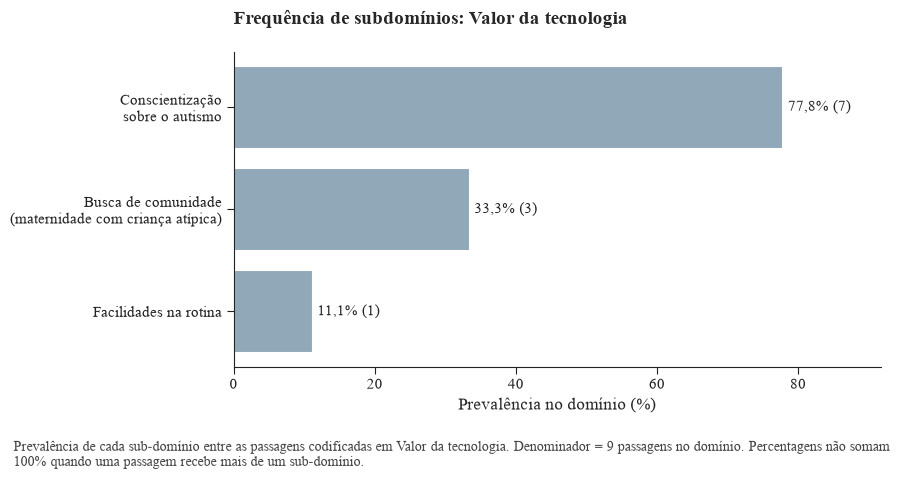

(                                         sub-domínio  passagens  \
 0                    Conscientização sobre o autismo          7   
 1  Busca de comunidade (maternidade com criança a...          3   
 2                              Facilidades na rotina          1   
 
   prevalência (%)  
 0           77,8%  
 1           33,3%  
 2           11,1%  ,
 <Figure size 900x480 with 1 Axes>)

In [31]:
plotar_categorias(
    data=df_longo,
    logica="hierarquia",
    dominio="Valor da tecnologia",
    agregacao_outros=False,
    titulo="Frequência de subdomínios: Valor da tecnologia",
    prevalencia=True,
    tabela=True,
    save_path="qual6.png",
)

### Frequência de subdomínios: parentalidade na era digital

,sub-domínio,passagens,prevalência (%)
0,Necessidade de controle/regulação,18,"47,4%"
1,Estratégias de imposição de limites,12,"31,6%"
2,Dificuldade em exercer autoridade,11,"28,9%"


Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/qual7.png


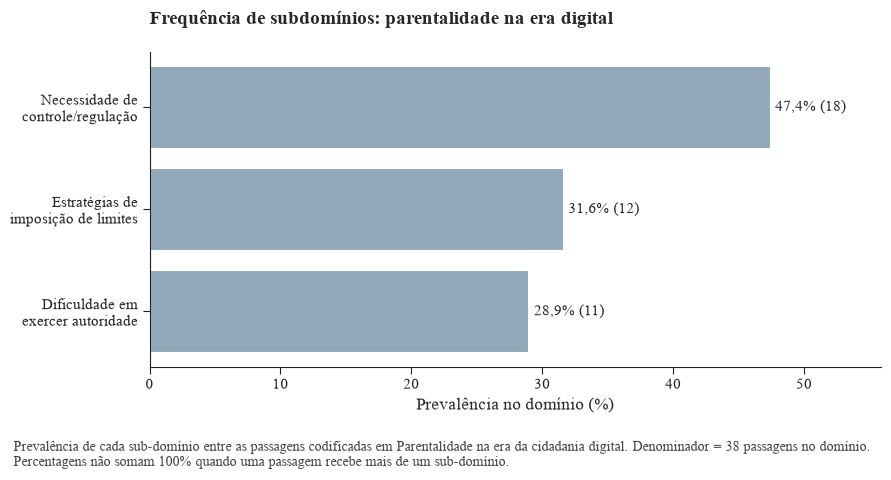

(                           sub-domínio  passagens prevalência (%)
 0    Necessidade de controle/regulação         18           47,4%
 1  Estratégias de imposição de limites         12           31,6%
 2    Dificuldade em exercer autoridade         11           28,9%,
 <Figure size 900x480 with 1 Axes>)

In [32]:
plotar_categorias(
    data=df_longo,
    logica="hierarquia",
    dominio="Parentalidade na era da cidadania digital",
    agregacao_outros=False,
    titulo="Frequência de subdomínios: parentalidade na era digital",
    prevalencia=True,
    tabela=True,
    save_path="qual7.png",
)

### Frequência de subdomínios: hábitos com tecnologia

,sub-domínio,passagens,prevalência (%)
0,Uso comum,12,"41,4%"
1,Obtenção e disseminação de informação (pais),9,"31,0%"
2,Muito tempo de tela,7,"24,1%"


Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/qual10.png


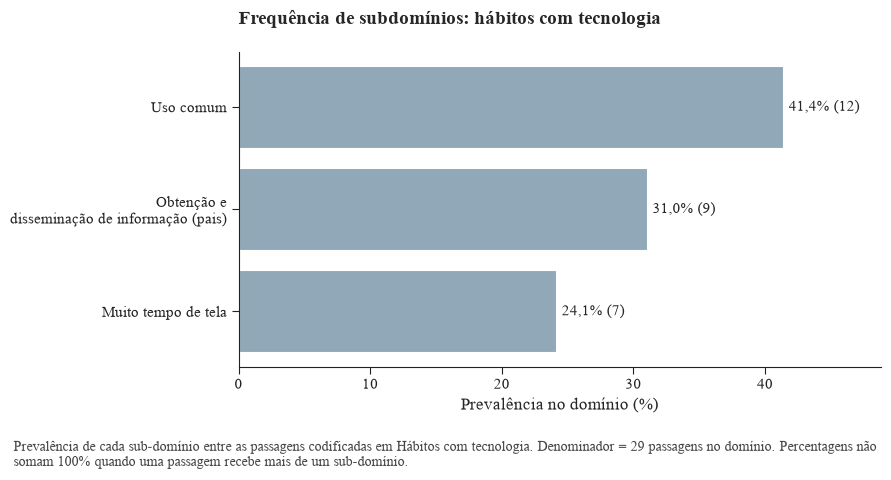

(                                    sub-domínio  passagens prevalência (%)
 0                                     Uso comum         12           41,4%
 1  Obtenção e disseminação de informação (pais)          9           31,0%
 2                           Muito tempo de tela          7           24,1%,
 <Figure size 900x480 with 1 Axes>)

In [33]:
plotar_categorias(
    data=df_longo,
    logica="hierarquia",
    dominio="Hábitos com tecnologia",
    agregacao_outros=False,
    titulo="Frequência de subdomínios: hábitos com tecnologia",
    prevalencia=True,
    tabela=True,
    save_path="qual10.png",
)

### Frequência de sub-domínios: o papel da tecnologia no desenvolvimento de crianças autistas

,sub-domínio,passagens,prevalência (%)
0,Formas alternativas de aprendizagem,7,"58,3%"
1,Ferramenta de revelação de competências anteri...,3,"25,0%"
2,Engajamento produtivo com tarefas adjacentes,2,"16,7%"


Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/qual12.png


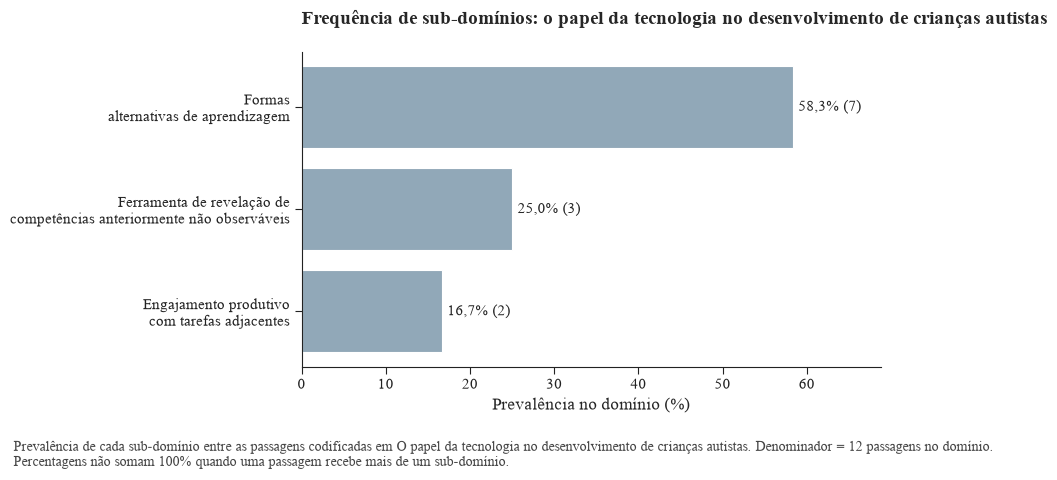

(                                         sub-domínio  passagens  \
 0                Formas alternativas de aprendizagem          7   
 1  Ferramenta de revelação de competências anteri...          3   
 2       Engajamento produtivo com tarefas adjacentes          2   
 
   prevalência (%)  
 0           58,3%  
 1           25,0%  
 2           16,7%  ,
 <Figure size 900x480 with 1 Axes>)

In [34]:
plotar_categorias(
    data=df_longo,
    logica="hierarquia",
    dominio="O papel da tecnologia no desenvolvimento de crianças autistas",
    agregacao_outros=False,
    titulo="Frequência de sub-domínios: o papel da tecnologia no desenvolvimento de crianças autistas",
    prevalencia=True,
    tabela=True,
    save_path="qual12.png",
)

### Sub-domínios detalhados

Barras horizontais com prevalência de cada **Sub-domínio detalhado** dentro de um caminho `Domínio › Sub-domínio`.

Denominador = passagens no caminho. Percentagens **não somam 100%** quando uma passagem recebe mais de um detalhado.

### Subdomínio detalhado: preocupação com a tecnologia

,sub-domínio detalhado,passagens,prevalência (%)
0,Conteúdo perigoso/deseducador/inapropriado,6,"46,2%"
1,Falta de controle das interações virtuais,5,"38,5%"
2,O digital é não amigável com crianças autistas,3,"23,1%"
3,Vício,2,"15,4%"


Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/qual3.png


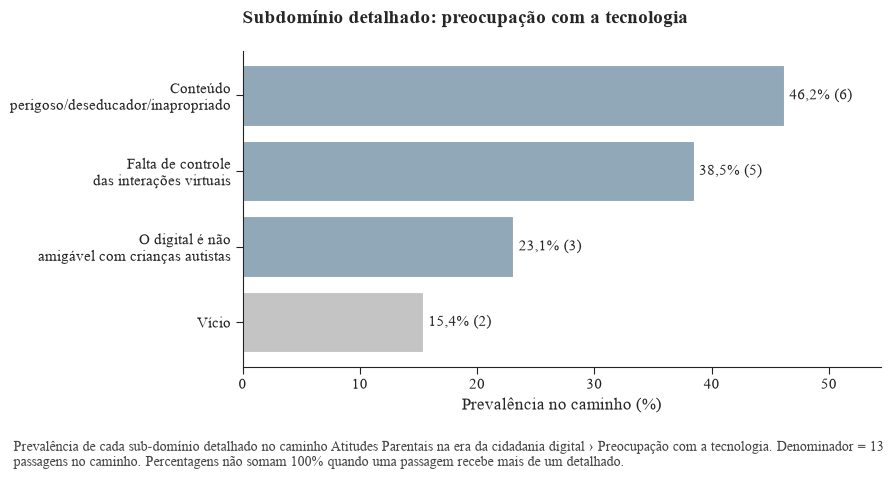

(                            sub-domínio detalhado  passagens prevalência (%)
 0      Conteúdo perigoso/deseducador/inapropriado          6           46,2%
 1       Falta de controle das interações virtuais          5           38,5%
 2  O digital é não amigável com crianças autistas          3           23,1%
 3                                           Vício          2           15,4%,
 <Figure size 900x480 with 1 Axes>)

In [35]:
plotar_categorias(
    data=df_longo,
    logica="subdominio_detalhado",
    dominio="Atitudes Parentais na era da cidadania digital",
    subdominio="Preocupação com a tecnologia",
    titulo="Subdomínio detalhado: preocupação com a tecnologia",
    prevalencia=True,
    tabela=True,
    save_path="qual3.png",
)

### Subdomínio detalhado: efeitos negativos no bem-estar infantil

,sub-domínio detalhado,passagens,prevalência (%)
0,Comportamento alterado,5,"55,6%"
1,Dessensibilização a conteúdo violento/inapropr...,2,"22,2%"
2,Isolamento/alheamento,2,"22,2%"
3,Medo/ansiedade,2,"22,2%"


Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/qual4.png


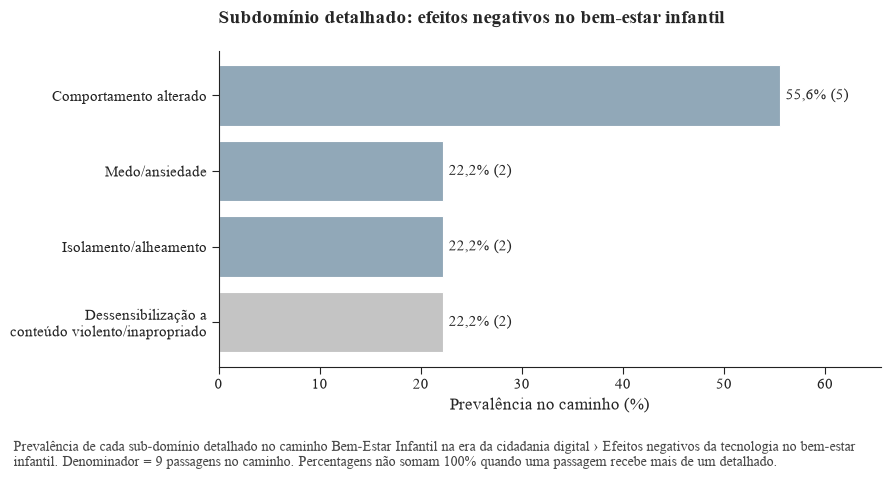

(                               sub-domínio detalhado  passagens  \
 0                             Comportamento alterado          5   
 1  Dessensibilização a conteúdo violento/inapropr...          2   
 2                              Isolamento/alheamento          2   
 3                                     Medo/ansiedade          2   
 
   prevalência (%)  
 0           55,6%  
 1           22,2%  
 2           22,2%  
 3           22,2%  ,
 <Figure size 900x480 with 1 Axes>)

In [36]:
plotar_categorias(
    data=df_longo,
    logica="subdominio_detalhado",
    dominio="Bem-Estar Infantil na era da cidadania digital",
    subdominio="Efeitos negativos da tecnologia no bem-estar infantil",
    titulo="Subdomínio detalhado: efeitos negativos no bem-estar infantil",
    prevalencia=True,
    tabela=True,
    save_path="qual4.png",
)

### Subdomínio detalhado: estratégia de imposição de limites

,sub-domínio detalhado,passagens,prevalência (%)
0,Diálogo,6,"50,0%"
1,Busca de formas alternativas para entreter,5,"41,7%"
2,Estabelecer e reforçar rotina,2,"16,7%"


Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/qual8.png


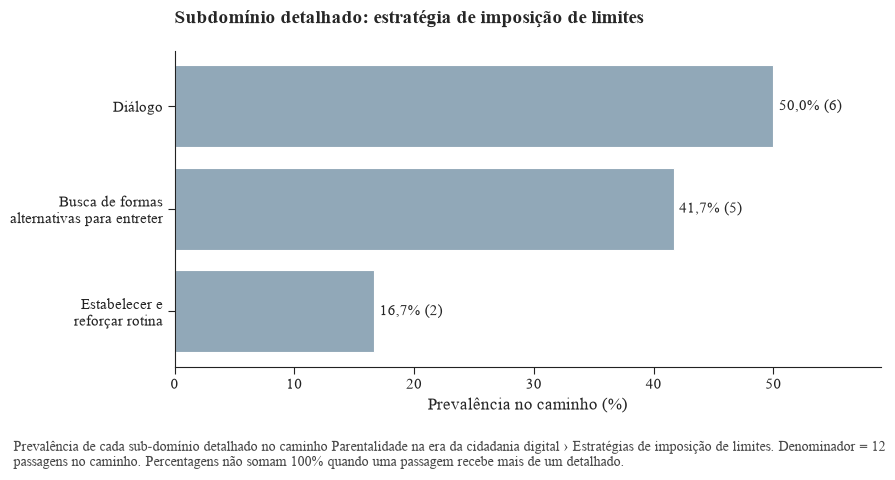

(                        sub-domínio detalhado  passagens prevalência (%)
 0                                     Diálogo          6           50,0%
 1  Busca de formas alternativas para entreter          5           41,7%
 2               Estabelecer e reforçar rotina          2           16,7%,
 <Figure size 900x480 with 1 Axes>)

In [37]:
plotar_categorias(
    data=df_longo,
    logica="subdominio_detalhado",
    dominio="Parentalidade na era da cidadania digital",
    subdominio="Estratégias de imposição de limites",
    titulo="Subdomínio detalhado: estratégia de imposição de limites",
    prevalencia=True,
    tabela=True,
    save_path="qual8.png",
)

### Subdomínio detalhado: Hábitos com tecnologia

,sub-domínio detalhado,passagens,prevalência (%)
0,Entretenimento (assistir desenho),8,"66,7%"
1,"Conteúdo virtual (influenciadores, vídeos curt...",3,"25,0%"
2,Jogos em geral,3,"25,0%"
3,Suporte educacional/aulas,3,"25,0%"
4,Jogos educacionais,1,"8,3%"


Imagem salva em: /Users/MaluEconomista/Documents/SIMONE_DISS/OUTPUT/qual11.png


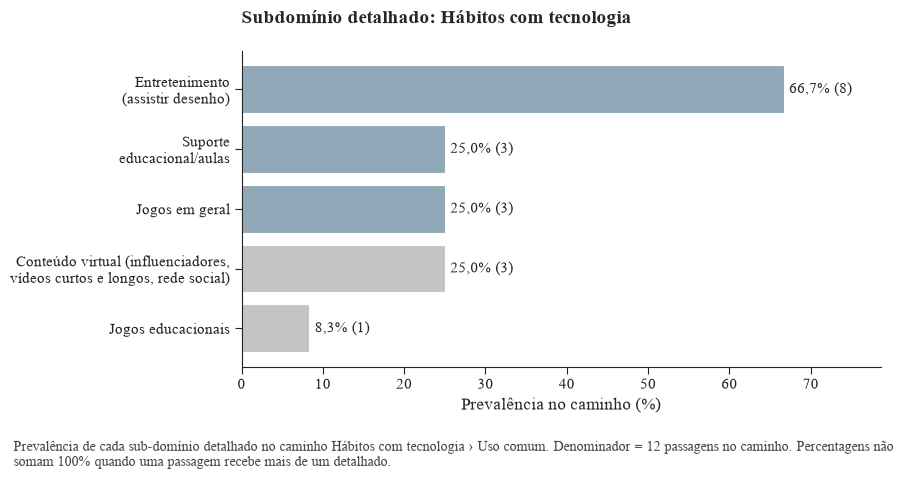

(                               sub-domínio detalhado  passagens  \
 0                  Entretenimento (assistir desenho)          8   
 1  Conteúdo virtual (influenciadores, vídeos curt...          3   
 2                                     Jogos em geral          3   
 3                          Suporte educacional/aulas          3   
 4                                 Jogos educacionais          1   
 
   prevalência (%)  
 0           66,7%  
 1           25,0%  
 2           25,0%  
 3           25,0%  
 4            8,3%  ,
 <Figure size 900x480 with 1 Axes>)

In [38]:
plotar_categorias(
    data=df_longo,
    logica="subdominio_detalhado",
    dominio="Hábitos com tecnologia",
    subdominio="Uso comum",
    titulo="Subdomínio detalhado: Hábitos com tecnologia",
    prevalencia=True,
    tabela=True,
    save_path="qual11.png",
)